# TS4: Primeras nociones de estimación espectral

Alumno: Felipe Berganza 

## RESUMEN

Este trabajo tiene como objetivo estudiar el comportamiento de estimadores espectrales aplicados a señales sinusoidales contaminadas con ruido blanco aditivo. En particular, se analiza cómo distintas ventanas de análisis afectan la estimación de parámetros fundamentales como la amplitud y la frecuencia de la señal, bajo diferentes condiciones de relación señal-ruido (SNR).

Se parte de la generación de señales sintéticas con frecuencia aleatoria centrada en un valor conocido, y se simulan múltiples realizaciones para evaluar estadísticamente el desempeño de los estimadores. Se aplican ventanas clásicas como Rectangular, Flattop, Blackman-Harris y Hann, y se calcula la Transformada Rápida de Fourier (FFT).

A lo largo del trabajo se evalúan métricas estadísticas clave como el sesgo y la varianza de los estimadores de amplitud y frecuencia mediante simulaciones de Monte Carlo, permitiendo comparar el impacto de cada ventana en la precisión de las estimaciones. Además, se visualizan los resultados mediante histogramas y gráficos de densidad espectral de potencia (PSD), lo que facilita la interpretación de los efectos del ventaneo, el ancho de banda equivalente de ruido (ENBW) y el nivel de SNR. 

## INTRODUCCION 

## Ventanas:

En este desarrollo se evalúa el desempeño estadístico y el impacto de cuatro tipos de ventanas clásicas sobre los estimadores de los parámetros de la señal:

Rectangular: Ofrece el lóbulo principal más angosto (máxima resolución de frecuencia) y la menor ganancia de ruido, pero sufre de la peor atenuación de lóbulos secundarios ($-13\text{ dB}$) y el mayor error de scalloping.

Hann: Una ventana de coseno alzado que reduce drásticamente los lóbulos secundarios a costa de duplicar el ancho del lóbulo principal, equilibrando la precisión en frecuencia y amplitud.

Blackman-Harris: Diseñada mediante una combinación lineal de términos cosenoidales, minimiza los lóbulos secundarios de forma extrema (baja atenuación de piso), ideal para rangos dinámicos amplios.

Flattop: Diseñada específicamente para instrumentación y metrología. Su lóbulo principal posee un tope plano que elimina prácticamente el error de scalloping en la medición de la amplitud, sacrificando severamente la resolución en frecuencia y aumentando la ganancia de ruido integrada (ENBW).

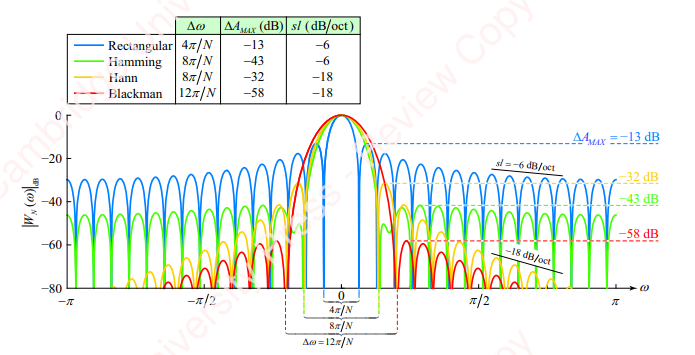

## Estimadores Espectrales:

En estadística y procesamiento de señales, un estimador es una función de los datos muestreados que se utiliza para inferir el valor de un parámetro poblacional desconocido (en este caso, la amplitud $A_0$ y la frecuencia $f_0$ de la sinusoide).

Dado que las señales reales están corrompidas por ruido aleatorio, los estimadores son variables aleatorias y su desempeño se evalúa mediante dos métricas fundamentales a través de simulaciones:

Sesgo (Bias): Es la diferencia entre el valor esperado del estimador y el valor real del parámetro. Un estimador es insesgado si su sesgo es cero.$$\text{Sesgo}(\hat{\theta}) = E[\hat{\theta}] - \theta_0$$

Varianza (Variance): Mide la dispersión de las estimaciones alrededor de su valor esperado debido al efecto del ruido y el espaciado de los bines.$$\text{Varianza}(\hat{\theta}) = E[(\hat{\theta} - E[\hat{\theta}])^2]$$

## 1. Estimador de Amplitud

Para una señal senoidal pura, la energía en el dominio de la frecuencia se concentra en un único punto del espectro. Al discretizar mediante la FFT y aplicar una ventana, la amplitud máxima observada en el espectro se reduce por un factor igual al promedio de la ventana (pérdida por ganancia continua).

Para corregir esta atenuación y recuperar el valor pico real de la señal, el estimador de amplitud que se utiliza en el script está definido por:

$$\hat{A} = \frac{2 \cdot \max(|X(f)|)}{\frac{1}{N}\sum_{n=0}^{N-1} w(n)}$$

Donde:

$\max(|X(f)|)$es el valor máximo del módulo de la FFT (normalizada por $1/N$).

El factor $2$ compensa que la energía de la sinusoide real se divide entre las frecuencias positivas y negativas del espectro.

$\frac{1}{N}\sum w(n)$ es el valor medio de la ventana (np.mean(w)), que compensa la pérdida de ganancia de amplitud introducida por el ventaneo.

## 2. Estimador de Frecuencia

El estimador de frecuencia más directo y simple en entornos discretos se basa en el principio de Máxima Verosimilitud bajo ruido blanco, el cual consiste en encontrar la posición del bin (índice) que contiene el valor absoluto máximo de la FFT dentro del espectro unilateral (frecuencias positivas):

$$\hat{k} = \arg\max_{0 \le k < \frac{N}{2}} |X(k)|$$

Para transformar este índice discreto $\hat{k}$ a una magnitud física de frecuencia en Hercios (Hz), se multiplica por la resolución espectral del sistema ($\Delta f = f_s / N$):$$\hat{f} = \hat{k} \cdot \Delta f = \hat{k} \cdot \frac{f_s}{N}$$

Donde:

$|X(k)|$ es el módulo de la FFT de la señal ventaneada.

$f_s$ es la frecuencia de muestreo ($1000\text{ Hz}$).

$N$ es la cantidad de puntos de la FFT.

# DESARROLLO 

## Calculo de estimadores en amplitud y frecuenicia

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft
import scipy.signal.windows as window
import scipy.stats as st


def señal (tt, frec, amp, SNR, R, fase=0, v_medio=0):

    N = len(tt)
    s = amp*np.sin(2*np.pi*frec*tt + fase) + v_medio
    if SNR == None:
      return s

    P_signal = np.var(s)
    P_noise  = P_signal / (10**(SNR/10))
    ruido_mat = np.random.normal (0, np.sqrt(P_noise), size=(N,R))
    return s + ruido_mat


#%% PARAMETROS 

fs = 1000
N = 1000
df = fs/N
R = 200
ff = np.arange (N) * df
ff_zp = fs * np.arange (10*N) / (10*N) #Zero Padding 


tt = np.arange (N) / fs                       
tt_col = tt.reshape (N, 1)                 
tt_mat = np.tile (tt_col, (1, R))            


frec_rand = np.random.uniform (-2, 2, R)     
frec = (N/4 + frec_rand) * df              
frec_fila = frec.reshape (1, R)               
frec_mat = np.tile (frec_fila, (N, 1))   

#%% DECLARACION DE VENTANAS 

# Modelo de señal (SNR en dB)

amp_0 = np.sqrt (2)
x1 = señal (tt = tt_mat, frec = frec_mat, amp = amp_0, SNR = 3, R = R)  # (NxR)
x2 = señal (tt = tt_mat, frec = frec_mat, amp = amp_0, SNR = 10, R = R) # (NxR)

# Generación de ventanas
w_rect = np.ones ((N, 1))                                  # Ventana rectangular (en realidad está implícita)
w_flat = window.flattop (N, sym=False).reshape(-1,1)       # Ventana Flattop
w_bh = window.blackmanharris (N, sym=False).reshape(-1,1)  # Ventana Blackman-Harris
w_hann = window.hann (N, sym=False).reshape(-1,1)          # Ventana Hann    

#%% VENTANEO Y FFTS 

# Ventaneo y FFT de la señal x1 (SNR = 3dB)

x1_rect = x1 * w_rect
x1_flat = x1 * w_flat
x1_bh   = x1 * w_bh
x1_hann = x1 * w_hann

X1_rect = (1/N) * fft(x1_rect, axis=0)
X1_flat = (1/N) * fft(x1_flat, axis=0)
X1_bh   = (1/N) * fft(x1_bh,   axis=0)
X1_hann = (1/N) * fft(x1_hann, axis=0)

# Con Zero Padding
X1_rect_zp = (1/N) * fft(x1_rect, n=10*N, axis=0)
X1_flat_zp = (1/N) * fft(x1_flat, n=10*N, axis=0)
X1_bh_zp   = (1/N) * fft(x1_bh, n=10*N,   axis=0)
X1_hann_zp = (1/N) * fft(x1_hann, n=10*N, axis=0)


# Ventaneo y FFT de la señal x2 (SNR = 10dB) 

x2_rect = x2 * w_rect
x2_flat = x2 * w_flat
x2_bh   = x2 * w_bh
x2_hann = x2 * w_hann

X2_rect = (1/N) * fft(x2_rect, axis=0)
X2_flat = (1/N) * fft(x2_flat, axis=0)
X2_bh   = (1/N) * fft(x2_bh,   axis=0)
X2_hann = (1/N) * fft(x2_hann, axis=0)

# Con Zero Padding
X2_rect_zp = (1/N) * fft(x2_rect, n=10*N, axis=0)
X2_flat_zp = (1/N) * fft(x2_flat, n=10*N, axis=0)
X2_bh_zp   = (1/N) * fft(x2_bh, n=10*N,   axis=0)
X2_hann_zp = (1/N) * fft(x2_hann, n=10*N, axis=0)

#%% ESTIMADORES EN AMPLITUD Y FRECUENCIA 

#  Estimadores de amplitud de la señal x1 (SNR = 3dB)  


ax1_rect = 2*np.max(np.abs(X1_rect), axis=0) / np.mean(w_rect)
ax1_flat = 2*np.max(np.abs(X1_flat), axis=0) / np.mean(w_flat)
ax1_bh   = 2*np.max(np.abs(X1_bh),   axis=0) / np.mean(w_bh)
ax1_hann = 2*np.max(np.abs(X1_hann), axis=0) / np.mean(w_hann)

sesgo_ax1_rect = np.mean (ax1_rect) - amp_0 
sesgo_ax1_flat = np.mean (ax1_flat) - amp_0
sesgo_ax1_bh   = np.mean (ax1_bh)   - amp_0
sesgo_ax1_hann = np.mean (ax1_hann) - amp_0

var_ax1_rect = np.var (ax1_rect) 
var_ax1_flat = np.var (ax1_flat) 
var_ax1_bh   = np.var (ax1_bh)
var_ax1_hann = np.var (ax1_hann)


#  Estimadores de amplitud de la señal x2 (SNR = 10dB) 


ax2_rect = 2*np.max(np.abs(X2_rect), axis=0) / np.mean(w_rect)
ax2_flat = 2*np.max(np.abs(X2_flat), axis=0) / np.mean(w_flat)
ax2_bh   = 2*np.max(np.abs(X2_bh),   axis=0) / np.mean(w_bh)
ax2_hann = 2*np.max(np.abs(X2_hann), axis=0) / np.mean(w_hann)

sesgo_ax2_rect = np.mean (ax2_rect) - amp_0
sesgo_ax2_flat = np.mean (ax2_flat) - amp_0
sesgo_ax2_bh   = np.mean (ax2_bh)   - amp_0
sesgo_ax2_hann = np.mean (ax2_hann) - amp_0

var_ax2_rect = np.var (ax2_rect)
var_ax2_flat = np.var (ax2_flat)
var_ax2_bh   = np.var (ax2_bh)
var_ax2_hann = np.var (ax2_hann)


#  Estimadores de frecuencia de la señal x1 (SNR = 3dB) 


fx1_rect = np.argmax ((np.abs(X1_rect[0:N//2, :])), axis=0)
fx1_flat = np.argmax ((np.abs(X1_flat[0:N//2, :])), axis=0)
fx1_bh   = np.argmax ((np.abs(X1_bh[0:N//2, :])),   axis=0)
fx1_hann = np.argmax ((np.abs(X1_hann[0:N//2, :])), axis=0)

sesgo_fx1_rect = np.mean (fx1_rect - frec_mat[N//4, :]) # ahora mi valor de frecuencia conocido ya no está fijo, debo barrer todas las realizaciones
sesgo_fx1_flat = np.mean (fx1_flat - frec_mat[N//4, :])
sesgo_fx1_bh   = np.mean (fx1_bh   - frec_mat[N//4, :])
sesgo_fx1_hann = np.mean (fx1_hann - frec_mat[N//4, :])

var_fx1_rect = np.var (fx1_rect)
var_fx1_flat = np.var (fx1_flat)
var_fx1_bh   = np.var (fx1_bh)
var_fx1_hann = np.var (fx1_hann)


#  Estimadores de frecuencia de la señal x2 (SNR = 10dB)


fx2_rect = np.argmax ((np.abs(X2_rect[0:N//2, :])), axis=0)
fx2_flat = np.argmax ((np.abs(X2_flat[0:N//2, :])), axis=0)
fx2_bh   = np.argmax ((np.abs(X2_bh  [0:N//2, :])), axis=0)
fx2_hann = np.argmax ((np.abs(X2_hann[0:N//2, :])), axis=0)

sesgo_fx2_rect = np.mean (fx2_rect - N//4)
sesgo_fx2_flat = np.mean (fx2_flat - N//4)
sesgo_fx2_bh   = np.mean (fx2_bh   - N//4)
sesgo_fx2_hann = np.mean (fx2_hann - N//4)

var_fx2_rect = np.var (fx2_rect)
var_fx2_flat = np.var (fx2_flat)
var_fx2_bh   = np.var (fx2_bh)
var_fx2_hann = np.var (fx2_hann)


#  Tablas 

print("\n")
print("========== Estimaciones de amplitud para Señal x1 (SNR = 3 dB) ==========")
print("{:<18} | {:>10} | {:>12}".format("Ventana", "Sesgo", "Varianza"))
print("-"*45)
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Rectangular", sesgo_ax1_rect, var_ax1_rect))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Flattop", sesgo_ax1_flat, var_ax1_flat))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Blackman-Harris", sesgo_ax1_bh, var_ax1_bh))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Hann", sesgo_ax1_hann, var_ax1_hann))

print("\n")
print("========== Estimaciones de amplitud para Señal x2 (SNR = 10 dB) ==========")
print("{:<18} | {:>10} | {:>12}".format("Ventana", "Sesgo", "Varianza"))
print("-"*45)
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Rectangular", sesgo_ax2_rect, var_ax2_rect))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Flattop", sesgo_ax2_flat, var_ax2_flat))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Blackman-Harris", sesgo_ax2_bh, var_ax2_bh))
print("{:<18} | {:>10.6f} | {:>12.8f}".format("Hann", sesgo_ax2_hann, var_ax2_hann))


#  Tabla de estimación de frecuencia 

print("\n")
print("========== Estimación de Frecuencia para Señal x1 (SNR = 3 dB) ==========")
print("{:<18} | {:>12} | {:>12}".format("Ventana", "Sesgo ", "Varianza "))
print("-"*46)
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Rectangular", sesgo_fx1_rect, var_fx1_rect))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Flattop", sesgo_fx1_flat, var_fx1_flat))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Blackman-Harris", sesgo_fx1_bh, var_fx1_bh))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Hann", sesgo_fx1_hann, var_fx1_hann))

print("\n")
print("========== Estimación de Frecuencia para Señal x2 (SNR = 10 dB) ==========")
print("{:<18} | {:>12} | {:>12}".format("Ventana", "Sesgo ", "Varianza "))
print("-"*46)
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Rectangular", sesgo_fx2_rect, var_fx2_rect))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Flattop", sesgo_fx2_flat, var_fx2_flat))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Blackman-Harris", sesgo_fx2_bh, var_fx2_bh))
print("{:<18} | {:>12.6f} | {:>12.8f}".format("Hann", sesgo_fx2_hann, var_fx2_hann))






========== Estimaciones de amplitud para Señal x1 (SNR = 3 dB) ==========
Ventana            |      Sesgo |     Varianza
---------------------------------------------
Rectangular        |  -0.189802 |   0.02400404
Flattop            |   0.004336 |   0.00404508
Blackman-Harris    |  -0.045979 |   0.00323757
Hann               |  -0.077351 |   0.00510284


========== Estimaciones de amplitud para Señal x2 (SNR = 10 dB) ==========
Ventana            |      Sesgo |     Varianza
---------------------------------------------
Rectangular        |  -0.190229 |   0.02460227
Flattop            |  -0.001472 |   0.00076349
Blackman-Harris    |  -0.048359 |   0.00193769
Hann               |  -0.079100 |   0.00448197


========== Estimación de Frecuencia para Señal x1 (SNR = 3 dB) ==========
Ventana            |       Sesgo  |    Varianza 
----------------------------------------------
Rectangular        |     0.006326 |   1.27840000
Flattop            |    -0.018674 |   1.31077500
Blackman-Harris

# Analisis de estimadores en Amplitud 

## SNR = 3 dB

Flattop: Es, por lejos, la mejor ventana para estimar amplitud. Presenta un sesgo prácticamente nulo ($0.0043$) y una varianza muy baja ($0.0040$). Esto se debe a que su lóbulo principal es plano en el tope.

Blackman-Harris y Hann: Muestran un comportamiento intermedio. Blackman-Harris logra la menor varianza de todo el grupo ($0.0032$) gracias a su excelente atenuación de lóbulos secundarios, pero a costa de un sesgo negativo mayor ($-0.045$).

Rectangular: Es la peor opción. Tiene el mayor sesgo negativo ($-0.189$) debido al severo spectral leakage (fuga espectral) y la mayor varianza ($0.024$), lo que la hace muy inestable con mucho ruido.

## SNR = 10 dB

Tendencia general: Al mejorar la relación señal-ruido, la varianza disminuye drásticamente en las ventanas no rectangulares (especialmente en Flattop y Blackman-Harris, que caen a valores del orden de $10^{-4}$ o $10^{-3}$). El sesgo se mantiene relativamente constante porque depende más de la geometría de la ventana que del ruido.

Flattop sigue dominando: Su sesgo se reduce aún más ($-0.0014$) y su varianza cae a $0.00076$. Confirma su diseño específico para mediciones precisas de amplitud.

Rectangular estancada: Notá que la ventana rectangular casi no mejora su varianza ($0.0246$) ni su sesgo. El ruido ya no es el factor limitante para ella, sino su propia naturaleza espectral deficiente.

Conclusión para Amplitud: La ventana Flattop es la ganadora indiscutida para medir amplitudes, sin importar si hay mucho o moderado ruido, cumpliendo con su propósito teórico.

# Analisis de estimadores en Frecuencia

## SNR = 3 dB

Blackman-Harris y Rectangular: Presentan los sesgos más bajos ($0.0013$ y $0.0063$ respectivamente). Blackman-Harris además ofrece la menor varianza ($1.2529$).

Flattop: Al revés de lo que pasaba en amplitud, acá es la que introduce mayor sesgo ($-0.0186$) y mayor varianza ($1.3107$). Su lóbulo principal tan ancho, que antes ayudaba a la amplitud, ahora introduce incertidumbre a la hora de localizar el centro exacto del pico de frecuencia en presencia de ruido.

## SNR = 10 dB

Comportamiento uniforme: Lo más llamativo de este caso es que Rectangular, Blackman-Harris y Hann dan exactamente los mismos resultados (Sesgo: $-0.0300$, Varianza: $1.2891$). Esto sucede típicamente cuando la resolución está limitada por el tamaño de los "bins" discretos de la FFT (la discretización de la frecuencia) y el algoritmo de detección simplemente cae en el mismo casillero espectral.

Flattop se mantiene rezagada: Sigue teniendo el peor desempeño, con mayor sesgo ($-0.0700$) y mayor varianza ($1.3351$).

Conclusión para Frecuencia: Las ventanas con lóbulos principales más angostos o con caídas rápidas (Blackman-Harris o incluso Hann/Rectangular dependiendo del algoritmo de interpolación que uses) son superiores a Flattop para localizar la frecuencia exacta.

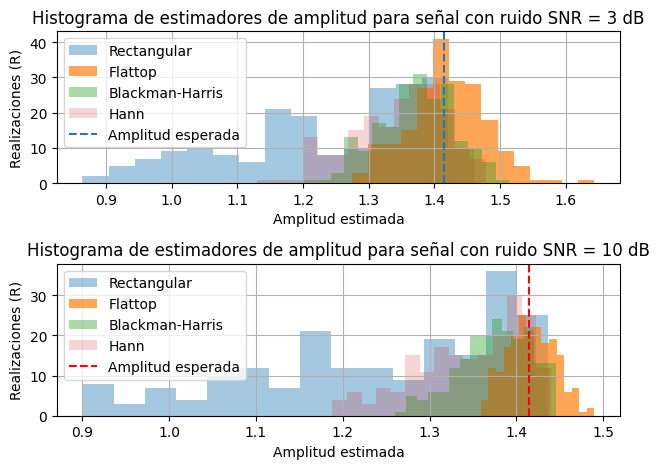

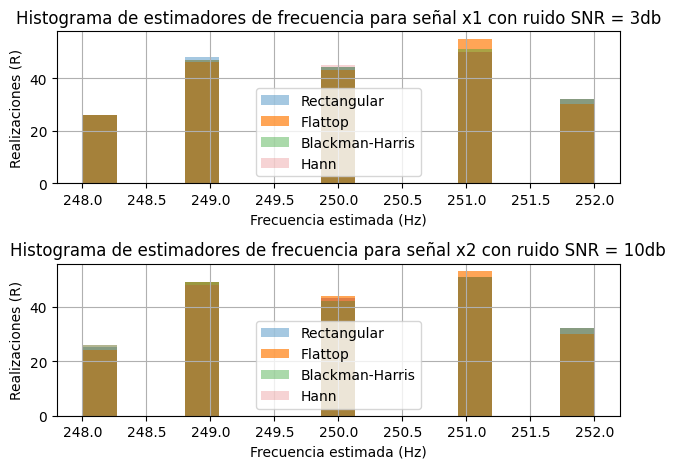

In [3]:
#  Ploteos estimadores de amplitud 


plt.figure (2)

plt.subplot (2, 1, 1)
plt.hist (ax1_rect, bins=15, alpha=0.4, label='Rectangular')
plt.hist (ax1_flat, bins=15, alpha=0.7, label='Flattop')
plt.hist (ax1_bh, bins=15, alpha=0.4, label='Blackman-Harris')
plt.hist (ax1_hann, bins=15, alpha=0.2, label='Hann')
plt.axvline (x=amp_0, linestyle='--', label='Amplitud esperada')
plt.title ('Histograma de estimadores de amplitud para señal con ruido SNR = 3 dB')
plt.ylabel ('Realizaciones (R)')
plt.xlabel ('Amplitud estimada')
plt.grid (True)
plt.legend ()

plt.subplot (2, 1, 2)
plt.hist (ax2_rect, bins=15, alpha=0.4, label='Rectangular')
plt.hist (ax2_flat, bins=15, alpha=0.7, label='Flattop')
plt.hist (ax2_bh, bins=15, alpha=0.4, label='Blackman-Harris')
plt.hist (ax2_hann, bins=15, alpha=0.2, label='Hann')
plt.axvline (x=amp_0, linestyle='--', color='red', label='Amplitud esperada')
plt.title ('Histograma de estimadores de amplitud para señal con ruido SNR = 10 dB')
plt.ylabel ('Realizaciones (R)')
plt.xlabel ('Amplitud estimada')
plt.grid (True)
plt.legend ()

plt.tight_layout ()
plt.show ()

# Ploteos de estimadores de frecuencia


plt.figure (3)

plt.subplot (2, 1, 1)
plt.hist (fx1_rect, bins=15, alpha=0.4, label='Rectangular')
plt.hist (fx1_flat, bins=15, alpha=0.7, label='Flattop')
plt.hist (fx1_bh, bins=15, alpha=0.4, label='Blackman-Harris')
plt.hist (fx1_hann, bins=15, alpha=0.2, label='Hann')
plt.title ('Histograma de estimadores de frecuencia para señal x1 con ruido SNR = 3db')
plt.ylabel ('Realizaciones (R)')
plt.xlabel ('Frecuencia estimada (Hz)')
plt.legend ()
plt.grid (True)

plt.subplot (2, 1, 2)
plt.hist (fx2_rect, bins=15,alpha=0.4, label='Rectangular')
plt.hist (fx2_flat, bins=15, alpha=0.7, label='Flattop')
plt.hist (fx2_bh, bins=15,alpha=0.4, label='Blackman-Harris')
plt.hist (fx2_hann, bins=15, alpha=0.2, label='Hann')
plt.title ('Histograma de estimadores de frecuencia para señal x2 con ruido SNR = 10db')
plt.ylabel ('Realizaciones (R)')
plt.xlabel ('Frecuencia estimada (Hz)')
plt.legend ()
plt.grid (True)

plt.tight_layout ()
plt.show ()



# Histogramas de Amplitud 

## SNR = 3 dB

Flattop (Naranja): Su campana está perfectamente partida a la mitad por la línea punteada azul. Esto visualiza el sesgo casi nulo que marcaban los datos. Es ancha debido al ruido, pero está en el lugar correcto.

Rectangular (Azul claro): Se ve claramente cómo está totalmente desplazada hacia la izquierda (subestimando la amplitud). Su distribución es chatísima y extendida desde $0.85$ hasta $1.3$, lo que ilustra de forma gráfica su enorme varianza y sesgo negativo.

Blackman-Harris (Verde) y Hann (Rosa): Están amontonadas un poco a la izquierda de la línea esperada (sesgo negativo moderado), pero sus campanas son notablemente más angostas y altas que la rectangular, reflejando su menor varianza.

## SNR = 10 dB

Al bajar el ruido, mirá cómo Flattop, Blackman-Harris y Hann se comprimen hacia el eje central. Sus distribuciones se vuelven más agudas (menor varianza). Flattop se abraza con fuerza a la línea roja esperada.

La Rectangular (Azul) sigue rota: A pesar de tener menos ruido, la distribución sigue dispersa y desplazada a la izquierda. Esto demuestra visualmente que el error de la ventana rectangular no era por el ruido, sino por el picket-fence effect intrínseco de su lóbulo principal angosto cuando la frecuencia no coincide con un bin exacto.

# Histograma de Frecuencia 

El fenómeno de la "Discretización" (Bins de la FFT): Los histogramas ya no son campanas continuas, sino barras aisladas y discretas en frecuencias exactas ($248$, $249$, $250$, $251$, $252\text{ Hz}$). Esto significa que el estimador está devolviendo directamente la posición del "bin" del vector de frecuencias de la FFT, sin una interpolación fina.

Por qué daban idénticos en SNR = 10 dB: En el último gráfico,  todas las ventanas están completamente solapadas una arriba de la otra (por eso el color es un marrón homogéneo mezclado). Al haber menos ruido, todas las realizaciones estadisticas caen exactamente en los mismos casilleros de frecuencia. No importa qué ventana se use; el limitante acá es la resolución en frecuencia de tu FFT ($\Delta f$).

El comportamiento de Flattop: (especialmente en los picos de las puntas en $248\text{ Hz}$ o $252\text{ Hz}$), la ventana Flattop (Naranja) suele sobresalir un poquito más en los extremos o diferir en los centros. Al tener un lóbulo principal tan ancho, el ruido arrastra más fácilmente la decisión del "pico" hacia bins vecinos falsos, lo que explicaba su mayor varianza y sesgo en la tabla anterior.


## CONCLUSION FINAL 

Como conclusión, el análisis comparativo demuestra que no existe una única ventana de enventanado ideal para todos los propósitos, sino que su elección estratégica depende del parámetro estimador bajo análisis: la ventana Flattop consolidó el mejor desempeño para la medición de amplitud al mitigar de forma óptima el sesgo por atenuación (picket-fence effect) incluso ante relaciones señal-ruido desfavorables ($\text{SNR} = 3\text{ dB}$); por el contrario, para la estimación de frecuencia, las ventanas con lóbulos principales más estrechos como Blackman-Harris y Hann resultaron superiores al ofrecer mayor selectividad espectral, evidenciando además que la precisión final de este último parámetro se encuentra fuertemente condicionada y limitada por la resolución discreta de los bins de la FFT.